# Uvod u PyTorch

Ovaj notebook je namenjen upoznavanju sa osnovama PyTorch-a kroz izgradnju višeslojnog perceptrona (MLP).

## Postavka

Prva ćelija uvozi potrebne biblioteke i priprema okruženje za treniranje MLP modela.

Importi:
- `torch`: glavna PyTorch biblioteka za izgradnju i treniranje neuronskih mreža.
- `torch.nn`: komponente neuronskih mreža kao što su slojevi i funkcije greške (loss function).
- `torch.optim`: podmodul sa algoritmima optimizacije kao što su SGD i Adam.
- `torchvision`: PyTorch paket sa popularnim skupovima podataka, arhitekturama modela i transformacijama slike.
- `matplotlib.pyplot`: biblioteka za crtanje grafikona i vizuelizaciju podataka i performansi modela.

Provera dostupnog uređaja:
- Proveravamo da li je dostupan GPU preko CUDA ili MPS podrške. Ako jeste, uređaj postavljamo na `cuda` ili `mps`, inače na `cpu`.
- Korišćenje GPU-a može značajno ubrzati treniranje većih neuronskih mreža.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Provera dostupnog uređaja: CUDA, zatim MPS, pa CPU
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)


## Priprema podataka

Ova ćelija priprema i učitava MNIST skup podataka koji koristimo za treniranje i testiranje MLP modela.

**Transformacije:**
- Definišemo transformaciju koja se primenjuje na slike:
  - `transforms.ToTensor()`: pretvara sliku u PyTorch tenzor.
  - `transforms.Normalize((0.5,), (0.5,))`: normalizuje sliku sa srednjom vrednošću i standardnom devijacijom `0.5`. Time se vrednosti piksela preslikavaju u opseg `[-1, 1]`.

**Skupovi podataka:**
- `train_dataset`: preuzima i učitava trening skup MNIST uz zadate transformacije.
- `test_dataset`: preuzima i učitava test skup MNIST uz iste transformacije.

In [2]:
# Definisanje transformacije za normalizaciju podataka
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Preuzimanje i učitavanje trening i test skupa
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

**DataLoader objekti:**
- `train_loader` je `DataLoader` za trening skup sa veličinom batch-a `64` i uključenim mešanjem podataka (shuffle). Mešanje pomaže da model ne nauči redosled podataka i poboljša generalizaciju.
- `test_loader` je `DataLoader` za test skup sa veličinom batch-a `64` i bez mešanja (Test skup ne moramo da mešamo - jedino je bitno da evulaciju radimo konzistentno).

In [3]:
# Kreiranje data loader-a
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


for images, labels in test_loader:
    print(f"Shape of images : {images.shape}") # shape: [B, C, H, W]
    print(f"Shape of labels: {labels.shape} {labels.dtype}")
    break


Shape of images : torch.Size([64, 1, 28, 28])
Shape of labels: torch.Size([64]) torch.int64


## Definicija modela

Inicijalizacija MLP modela za klasifikaciju MNIST slika.

Klasa `MLP`:
- Nasleđuje `nn.Module`.
- Metoda `__init__`:
  - Inicijalizuje MLP sa jednim skrivenim slojem od `128` neurona i izlaznim slojem od `10` neurona.
  - `nn.Linear(784, 128)`: ulazni sloj sa `784` ulaznih obeležja (`28x28` piksela) i `128` izlaza.
  - `nn.ReLU()`: primenjuje ReLU aktivacionu funkciju kako bi mreža bila nelinearna.
  - `nn.Linear(128, 10)`: izlazni sloj sa `10` klasa.

- Metoda `forward`:
  - Definiše kako se podaci obrađuju unutar mreže.
  - `x.view(x.size(0), -1)`: pretvara ulazni tenzor u 2D tenzor oblika `(B, 784)`.
  - `return self.layers(x)`: prosleđuje ulaz kroz slojeve definisane u `layers` i vraća predikciju.

Inicijalizacija modela:
- Kreira instancu klase `MLP` i prebacuje je na odgovarajući uređaj za treniranje (npr. `GPU`).


In [4]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 128),  # Ulazni sloj (28*28 = 784)
            nn.ReLU(),
            nn.Linear(128, 10)   # Izlazni sloj (10 klasa)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Sploštavanje slike (flatten)
        return self.layers(x)

# Kreiranje modela i prebacivanje na odgovarajući uređaj
model = MLP().to(device)


## Treniranje modela

Da bismo trenirali model treba nam funkcija greške (loss function) i optimizator (optimizer).

- `loss_fn = nn.CrossEntropyLoss()`: definiše funkciju greške `Cross-Entropy Loss`, često korišćenu za klasifikaciju.
- `optimizer = optim.Adam(model.parameters(), lr=0.001)`: postavlja `Adam` optimizator sa stopom učenja `0.001`.

In [5]:
# Funkcija greške i optimizator
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Model (mreža) pravi predikcije nad datim podacima iz jednog batch-a trening skupa, a zatim propagira grešku unazad kako bi prilagodio parametre modela.

**Funkcija za treniranje:**
- `train(model, device, train_loader, optimizer, loss_fn)`: trenira model tokom jedne epohe.
  - `model.train()`: postavlja model u režim treniranja.
  - `for batch_idx, (images, labels) in enumerate(train_loader)`: prolazi kroz trening skup po batch-evima.
  - `images, labels = images.to(device), labels.to(device)`: prebacuje podatke i oznake na izabrani uređaj.
  - `optimizer.zero_grad()`: poništava gradijente pre sledećeg prolaza unazad.
  - `prediction = model(images)`: izvršava prolaz unapred i računa predikcije.
  - `loss = loss_fn(prediction, labels)`: računa grešku između predikcija i tačnih oznaka.
  - `loss.backward()`: računa gradijente funkcije greške u odnosu na parametre modela.
  - `optimizer.step()`: ažurira parametre modela na osnovu izračunatih gradijenata.

**Petlja treniranja:**
- `for epoch in range(10)`: trenira model kroz `10` epoha.
  - `train(model, device, train_loader, optimizer, loss_fn)`: poziva funkciju za jednu epohu treniranja.
  - `print(f'Epoha {epoch+1} završena.')`: ispisuje poruku po završetku svake epohe.

Na ovaj način mreža uči iz trening podataka minimizacijom funkcije greške i ažuriranjem svojih parametara pomoću Adam optimizatora.


In [6]:
# Funkcija greške i optimizator
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Funkcija za treniranje
def train(model, device, train_loader, optimizer, loss_fn):
    model.train()
    running_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Forward
        images, labels = images.to(device), labels.to(device)
        prediction = model(images)
        loss = loss_fn(prediction, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    return running_loss / len(train_loader)

# Treniranje modela
for epoch in range(10):
    avg_loss = train(model, device, train_loader, optimizer, loss_fn)
    print(f'Epoch {epoch+1} complete. Average train loss: {avg_loss:.5f}')

Epoch 1 complete. Average train loss: 0.39334
Epoch 2 complete. Average train loss: 0.20253
Epoch 3 complete. Average train loss: 0.14710
Epoch 4 complete. Average train loss: 0.11795
Epoch 5 complete. Average train loss: 0.09995
Epoch 6 complete. Average train loss: 0.08802
Epoch 7 complete. Average train loss: 0.07956
Epoch 8 complete. Average train loss: 0.07015
Epoch 9 complete. Average train loss: 0.06467
Epoch 10 complete. Average train loss: 0.05937


## Evaluacija modela

Na kraju procenjujemo performanse modela na test skupu.

Funkcija: `evaluate`
- **Argumenti:**
  - `model (torch.nn.Module)`: neuronska mreža koju evaluiramo.
  - `test_loader (torch.utils.data.DataLoader)`: `DataLoader` za test skup.

- **Povratne vrednosti:**
  - lista vrednosti greške u batch-u tokom evaluacije.
  - lista tačnosti u batch-u tokom evaluacije.

- **Šta funkcija radi:**
  - `model.eval()`: prebacuje model u režim evaluacije.
  - `with torch.no_grad()`: isključuje računanje gradijenata, što smanjuje potrošnju memorije i ubrzava evaluaciju.
  - Za svaki batch iz `test_loader`:
    - prebacuje podatke i labele na izabrani uređaj,
    - izvršava prolaz unapred,
    - računa grešku i sabira je,
    - određuje predviđenu klasu kao indeks najveće log-verovatnoće,
    - poredi predikcije sa tačnim oznakama i sabira broj pogodaka,
    - računa i čuva tačnost za svaki batch.
  - Na kraju računa ukupnu tačnost i prosečnu grešku preko svih batch-eva.
  - Ispisuje ukupnu tačnost na testu i prosečnu grešku.


In [7]:
import matplotlib.pyplot as plt
import torch

def evaluate(model, test_loader):
    model.eval()
    total_correct = 0
    batch_accuracies = []
    total_loss = 0.0
    batch_losses = []

    with torch.no_grad():
        for images, labels in test_loader:
            # Forward
            images, labels = images.to(device), labels.to(device)
            prediction = model(images)

            # Izračunaj grešku za batch
            loss = loss_fn(prediction, labels)
            total_loss += loss.item()
            batch_losses.append(loss.item())

            correct_in_batch = (prediction.argmax(1) == labels).float().sum().item()
            total_correct += correct_in_batch

            # Izračunaj tačnost za batch (%) i sačuvaj
            batch_accuracy = correct_in_batch / images.size(0)
            batch_accuracies.append(batch_accuracy * 100)

    accuracy = total_correct / len(test_loader.dataset)
    average_loss = total_loss / len(test_loader)

    print(f'Test tačnost: {accuracy * 100:.2f}%')
    print(f'Test greška: {average_loss:.4f}')

    return batch_losses, batch_accuracies

eval_res = evaluate(model, test_loader)

Test tačnost: 96.94%
Test greška: 0.1039


## Vizuelizacija performansi

Ova funkcija iscrtava vrednosti greške (loss) i tačnosti (accuracy) zabeležene po svakom batch-u tokom evaluacije na dva uporedna grafikona.

**Funkcionalnost:**
- **Grafik greške:** Prikazuje promenu loss-a kroz batch-eve (zelena linija). 
  - X-osa: broj batch-a, 
  - Y-osa: vrednost greške (što manje to bolje).
- **Grafik tačnosti:** Prikazuje procenat tačnosti kroz batch-eve (plava linija).
  - X-osa: broj batch-a, 
  - Y-osa: procenat tačnosti (što više to bolje).

In [8]:
def plot_results(batch_losses, batch_accuracies):
    plt.figure(figsize=(12, 4))
    
    # Grafik greške
    plt.subplot(1, 2, 1)
    plt.plot(batch_losses, color='g')
    plt.title('Loss per Batch')
    plt.xlabel('Batch')
    plt.grid(True, alpha=0.3)

    # Grafik tačnosti
    plt.subplot(1, 2, 2)
    plt.plot(batch_accuracies, color='b')
    plt.title('Accuracy (%) per Batch')
    plt.xlabel('Batch')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Test tačnost: 96.94%
Test greška: 0.1039


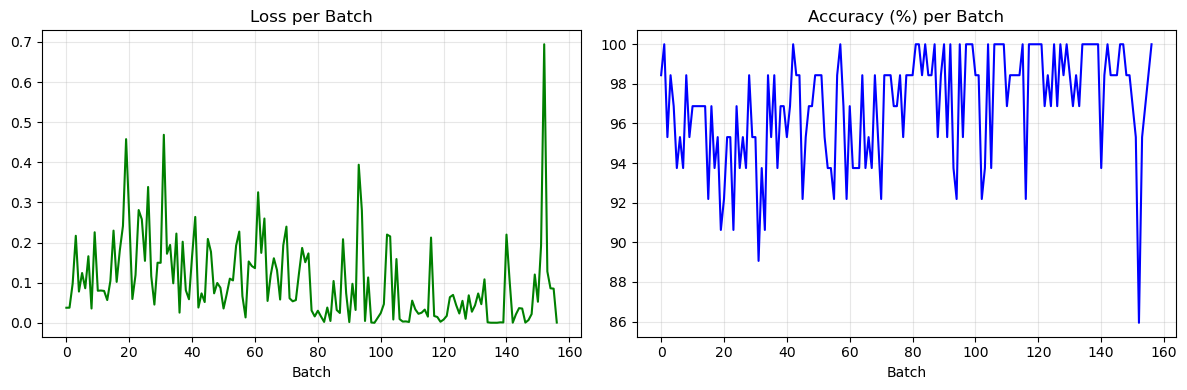

In [9]:
# Evaluacija i vizuelizacija
losses, accs = evaluate(model, test_loader)
plot_results(losses, accs)

Ovaj notebook je prilagođen na osnovu materijala [EEML 2025](https://github.com/eemlcommunity/PracticalSessions2025) . Copyright (c) 2025 EEML.